Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Weak reciprocity   |   δ = 0.1,  α = 0.1


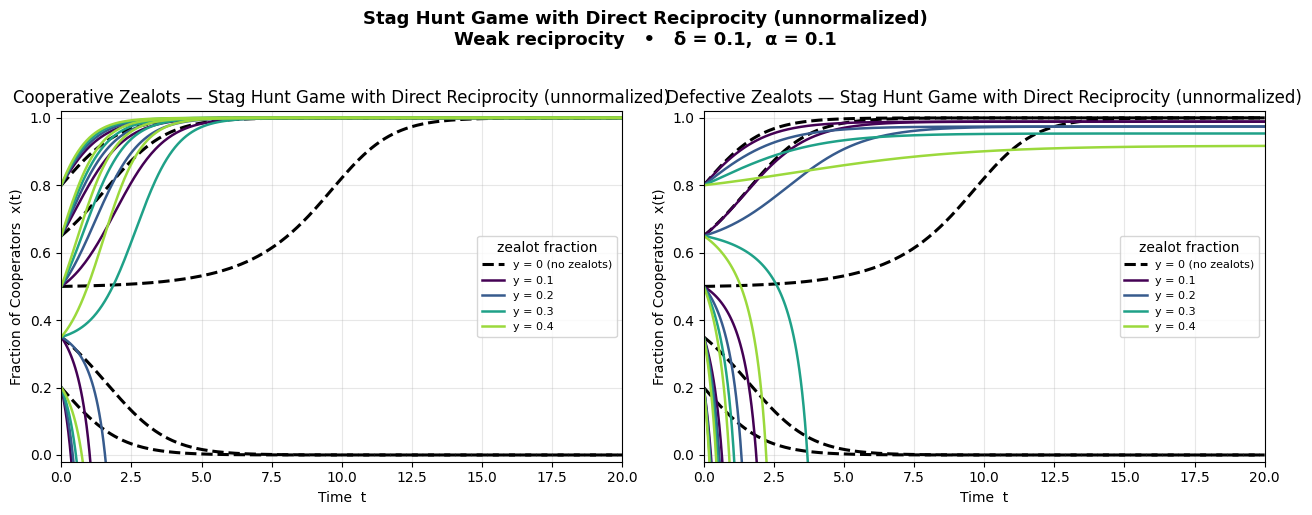

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Weak reciprocity   |   δ = 0.3,  α = 0.1


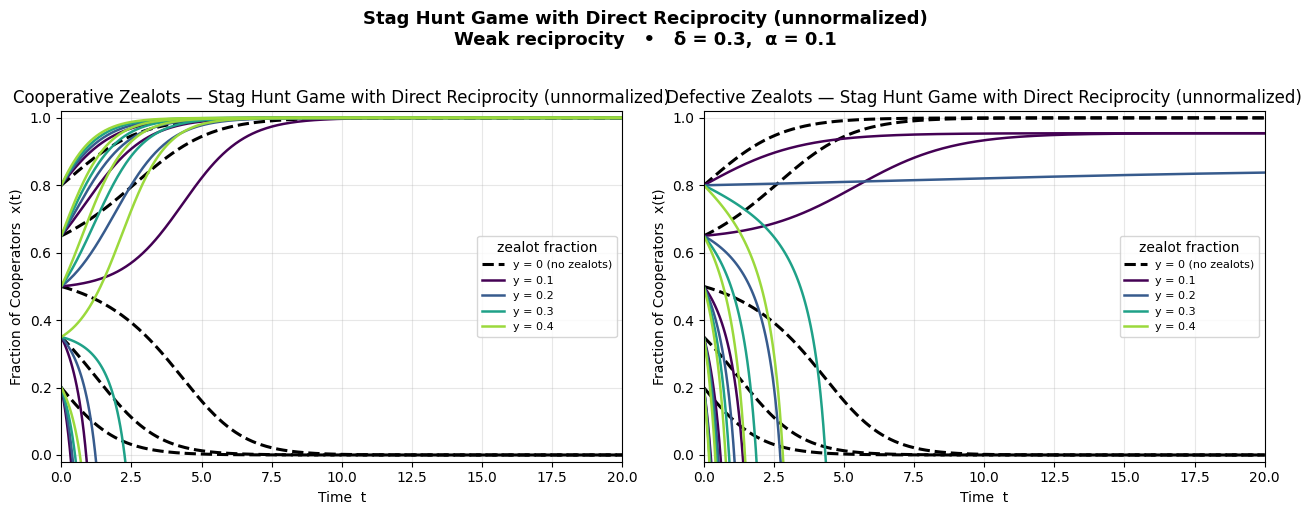

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Weak reciprocity   |   δ = 0.5,  α = 0.1


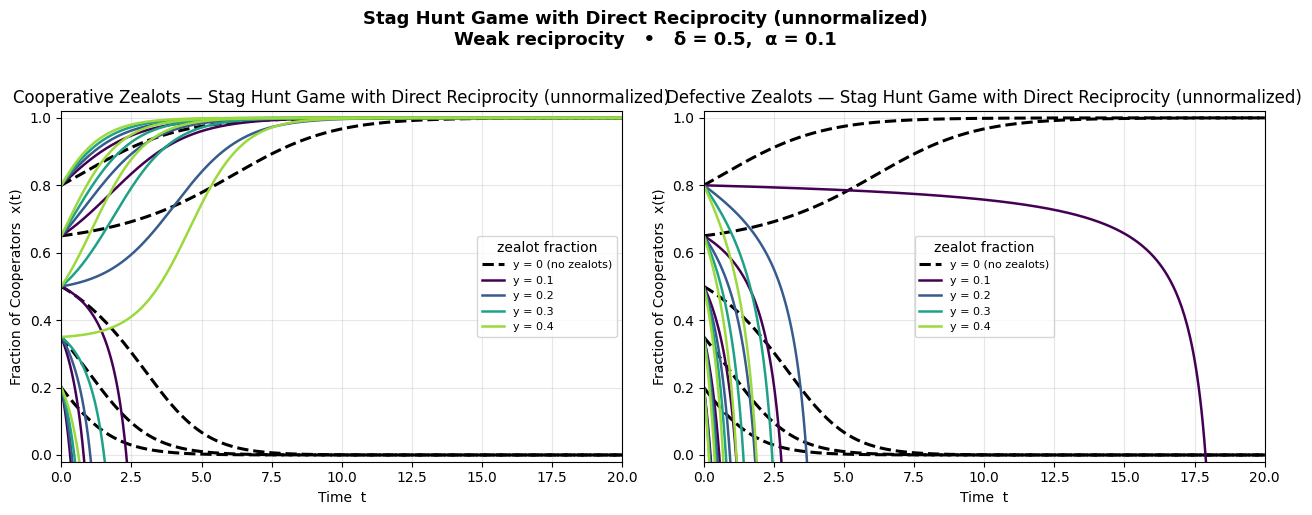

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Weak reciprocity   |   δ = 0.7,  α = 0.1


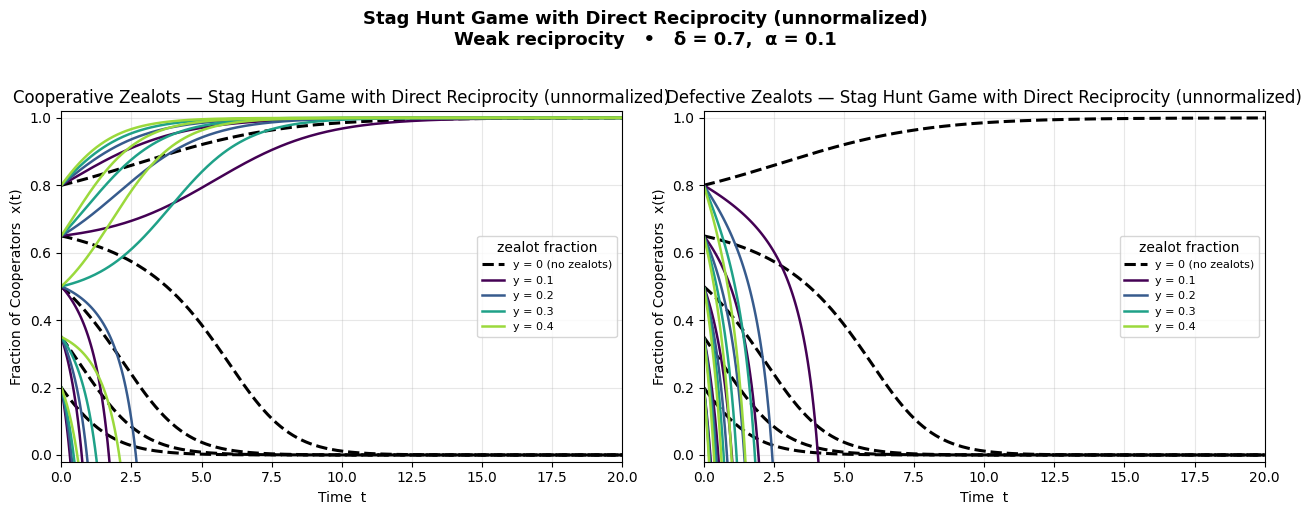

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Weak reciprocity   |   δ = 0.9,  α = 0.1


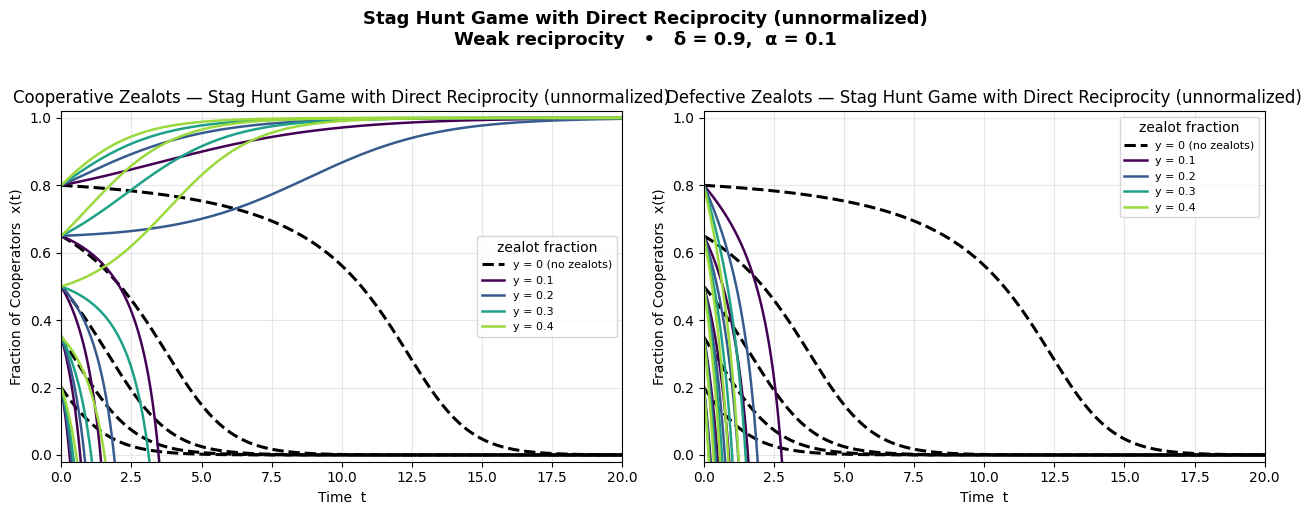

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.1,  α = 0.3


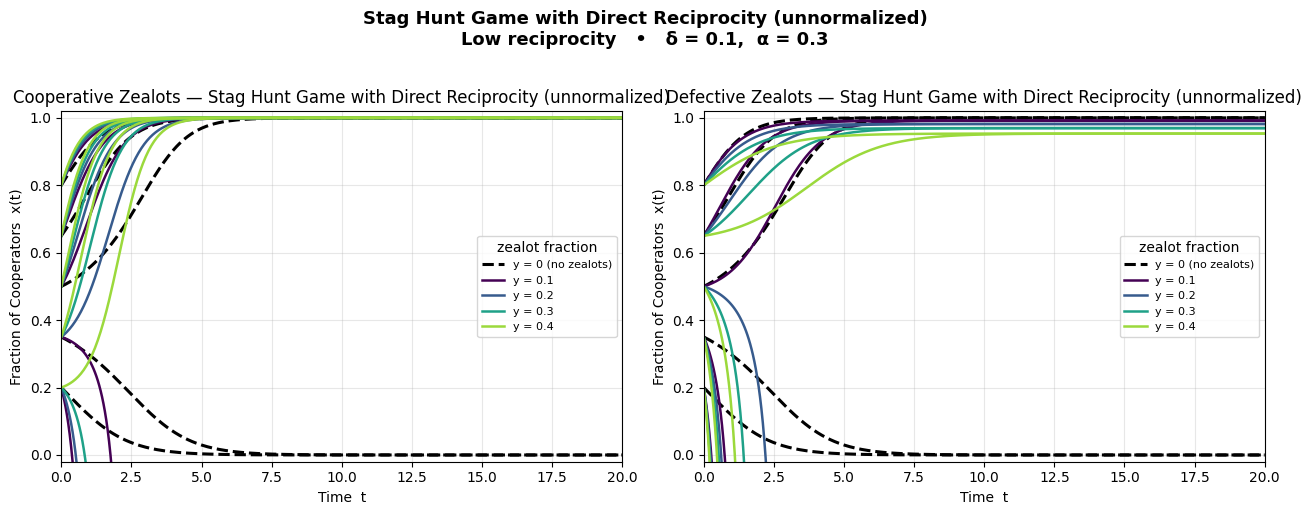

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.3,  α = 0.3


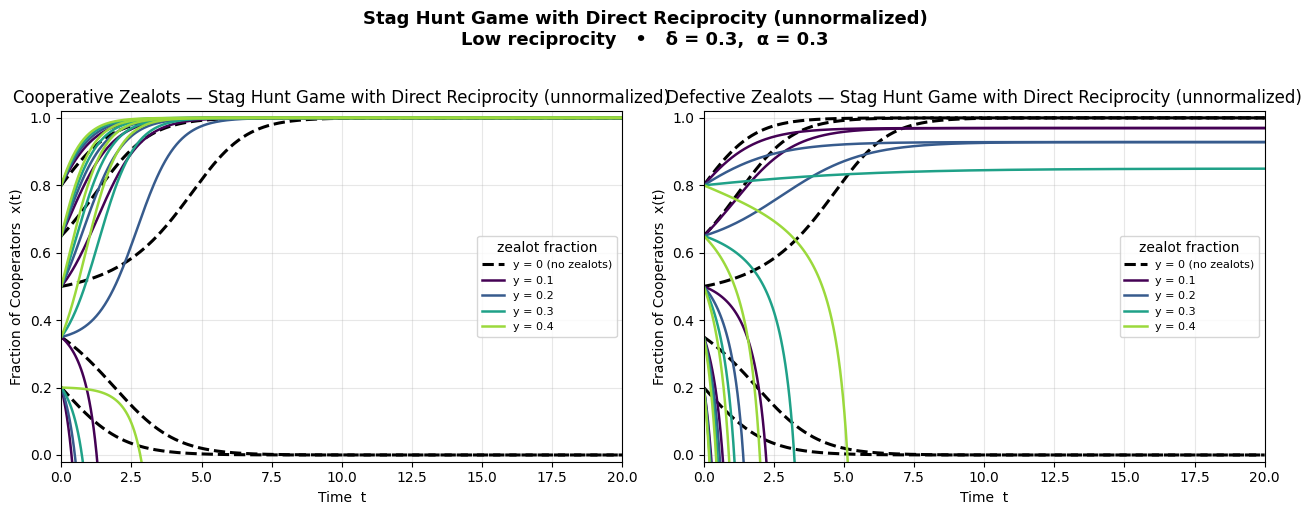

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.5,  α = 0.3


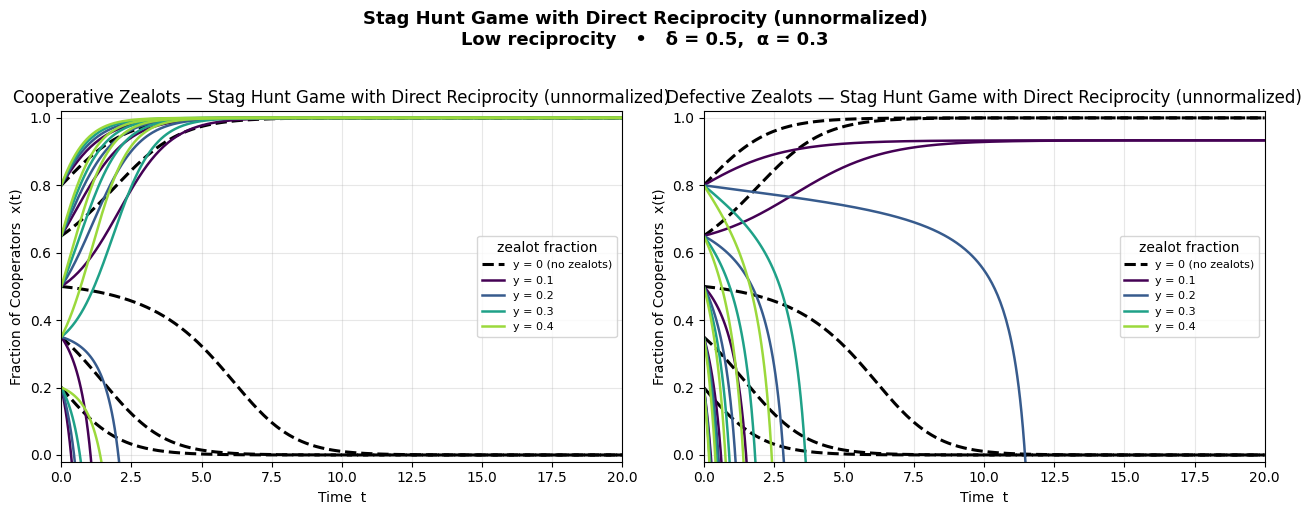

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.7,  α = 0.3


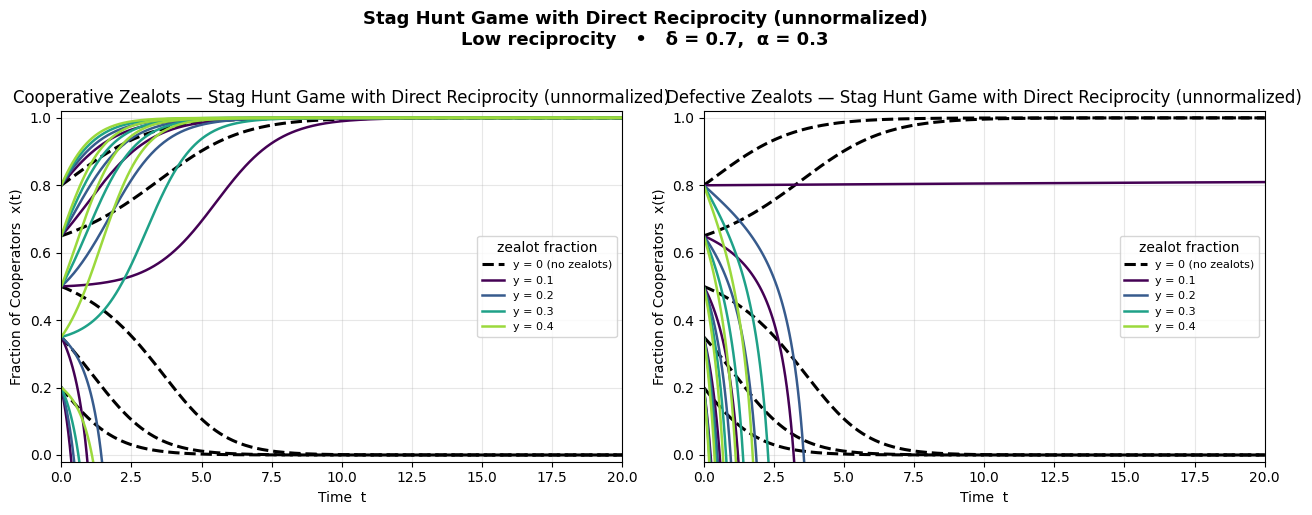

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.9,  α = 0.3


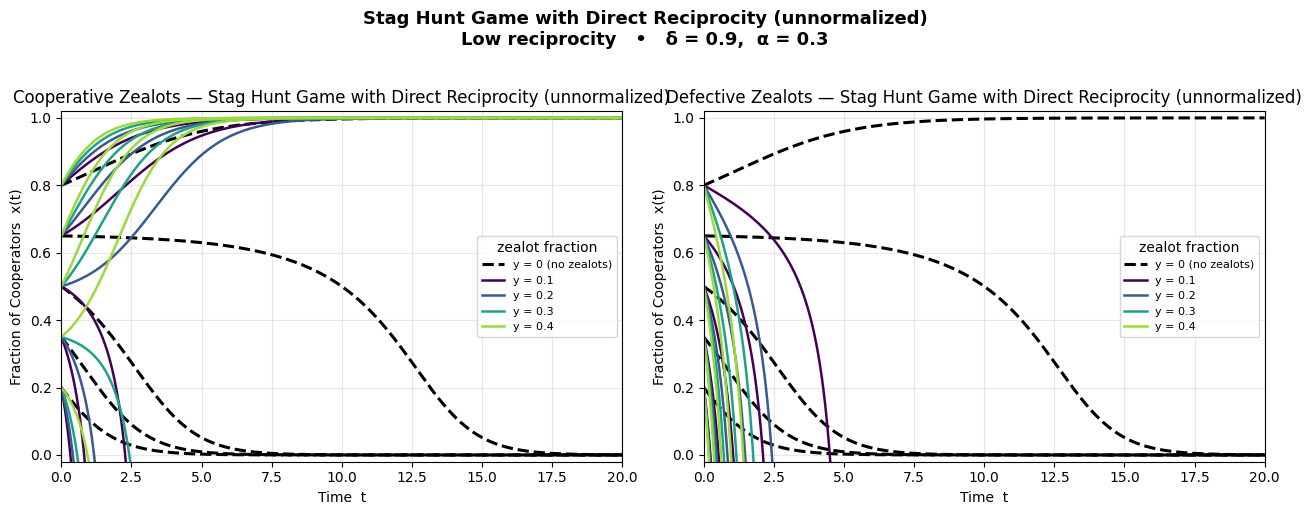

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.1,  α = 0.5


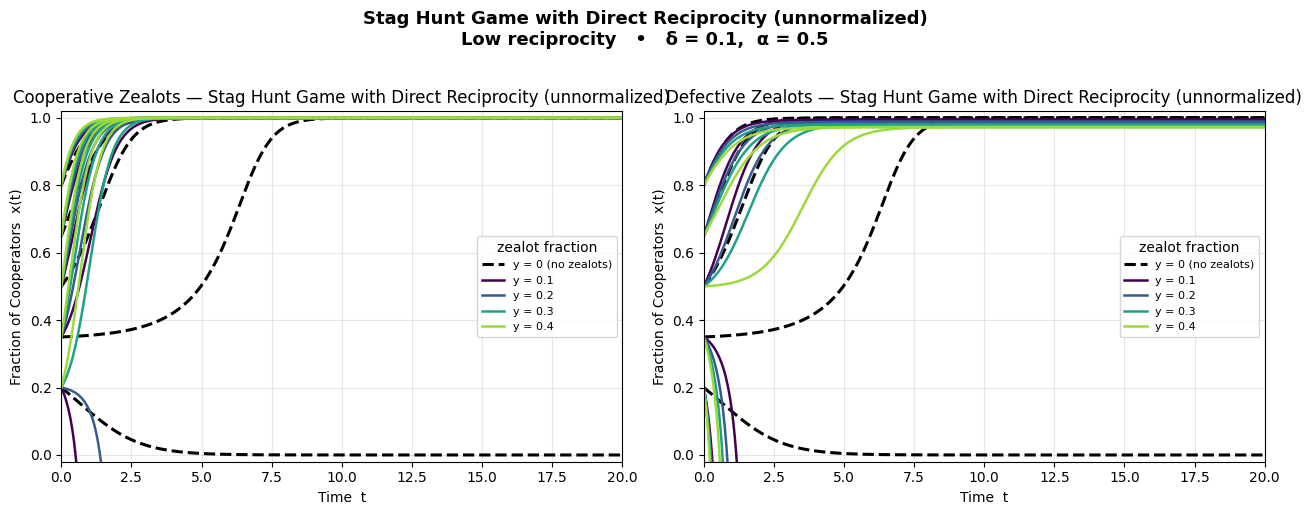

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.3,  α = 0.5


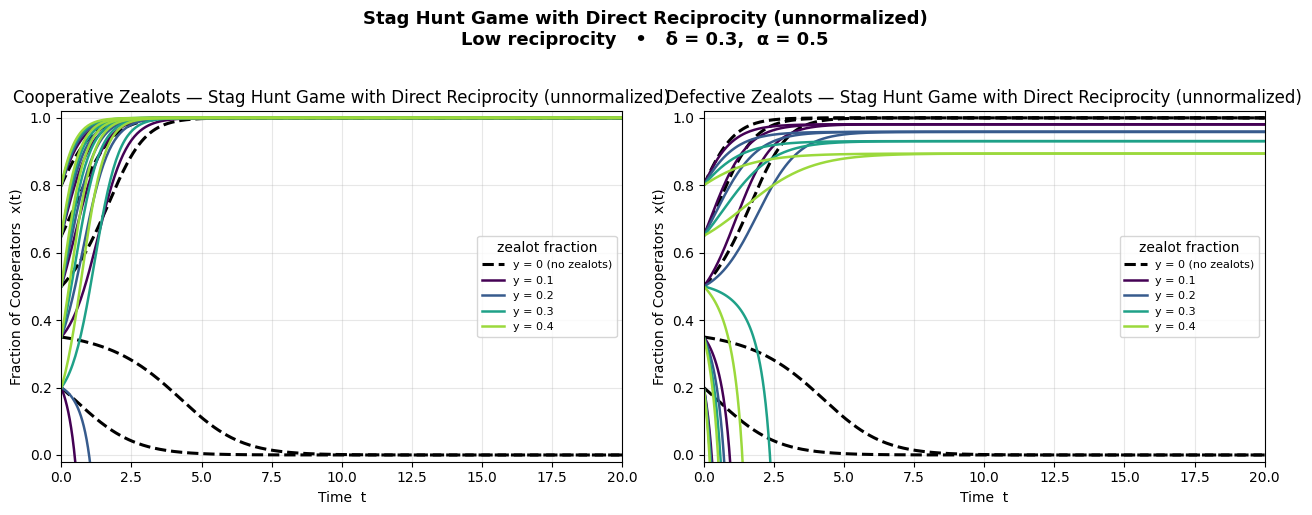

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.5,  α = 0.5


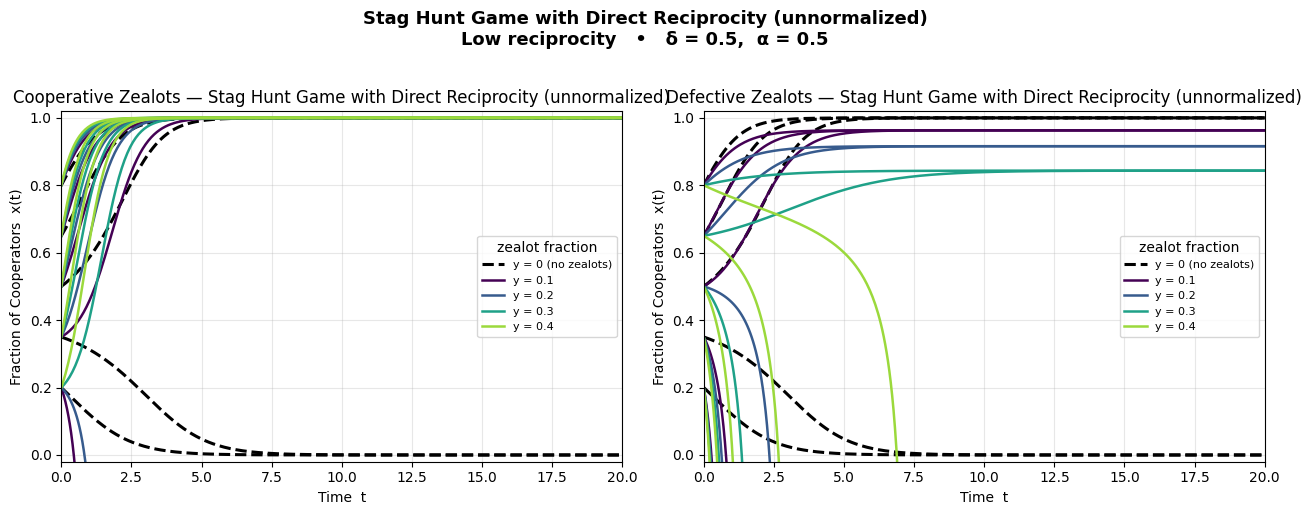

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.7,  α = 0.5


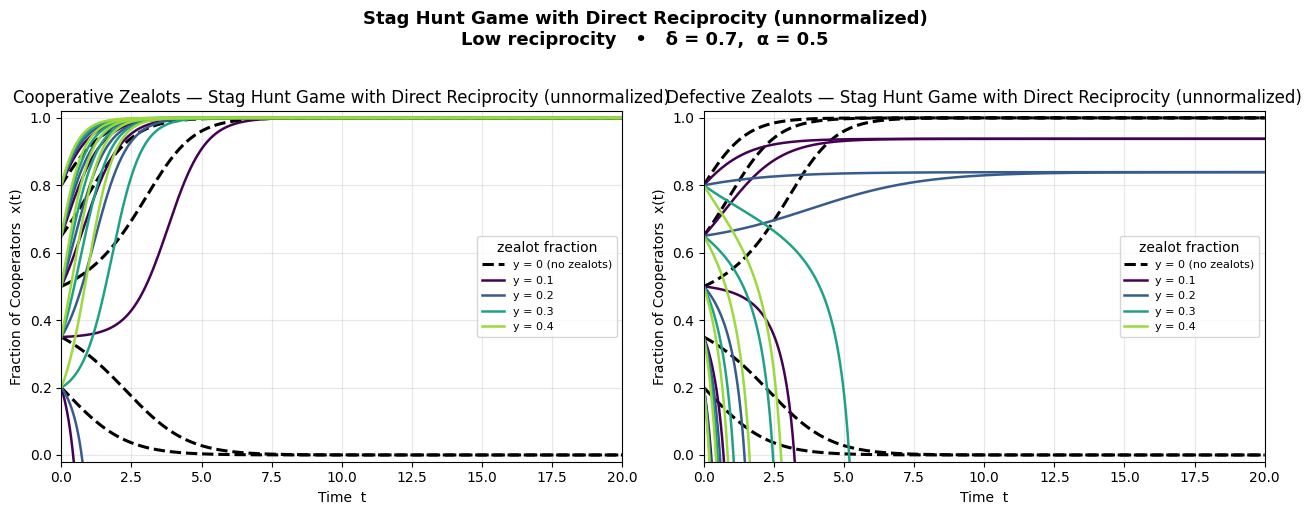

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Low reciprocity   |   δ = 0.9,  α = 0.5


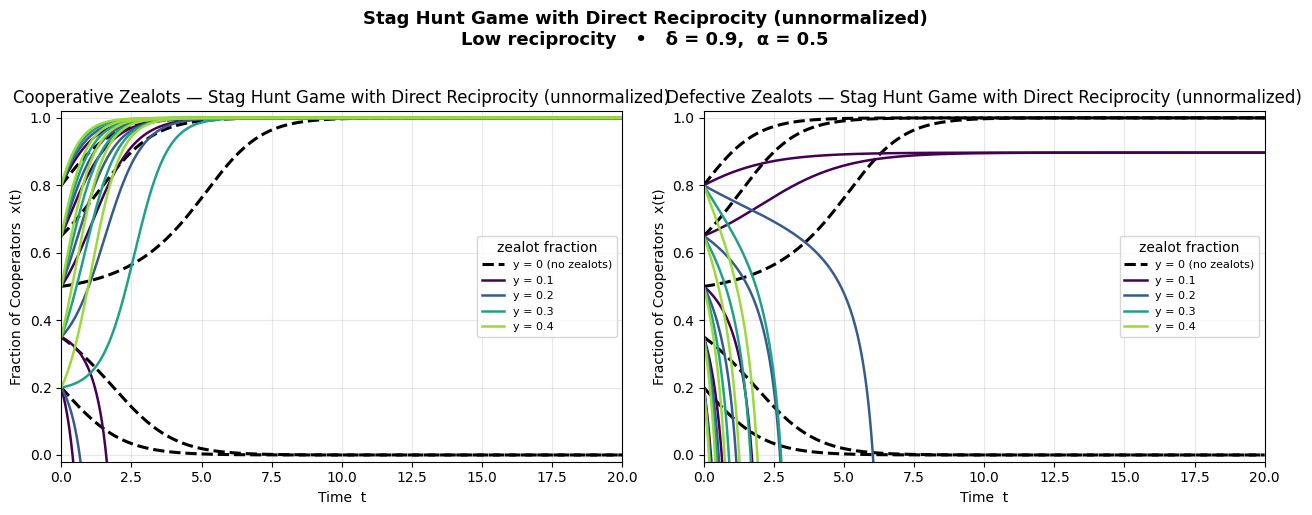

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Moderate reciprocity   |   δ = 0.1,  α = 0.7


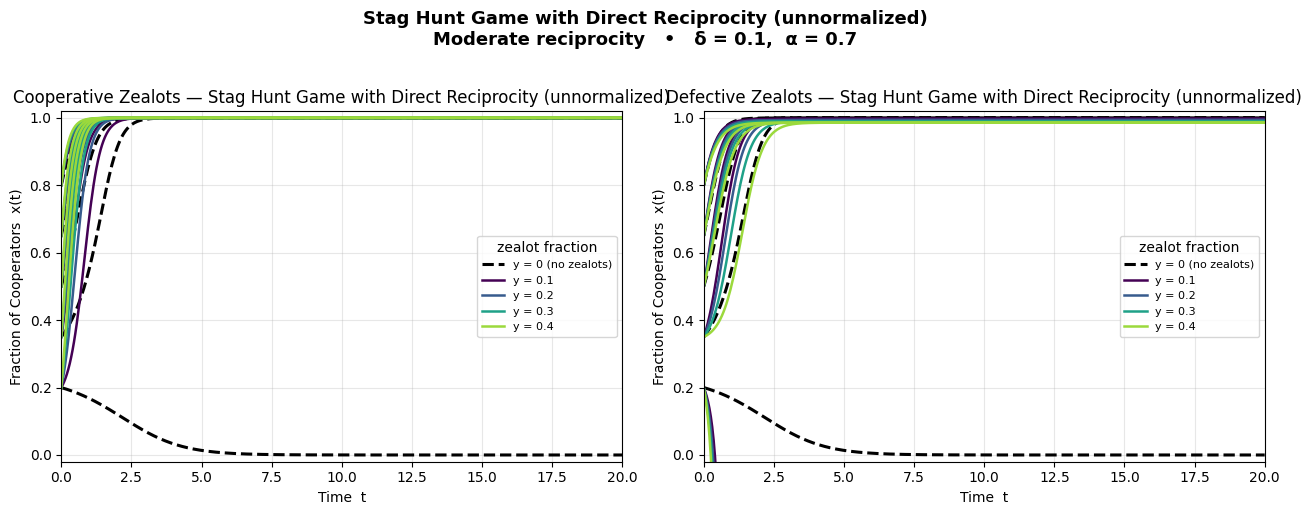

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Moderate reciprocity   |   δ = 0.3,  α = 0.7


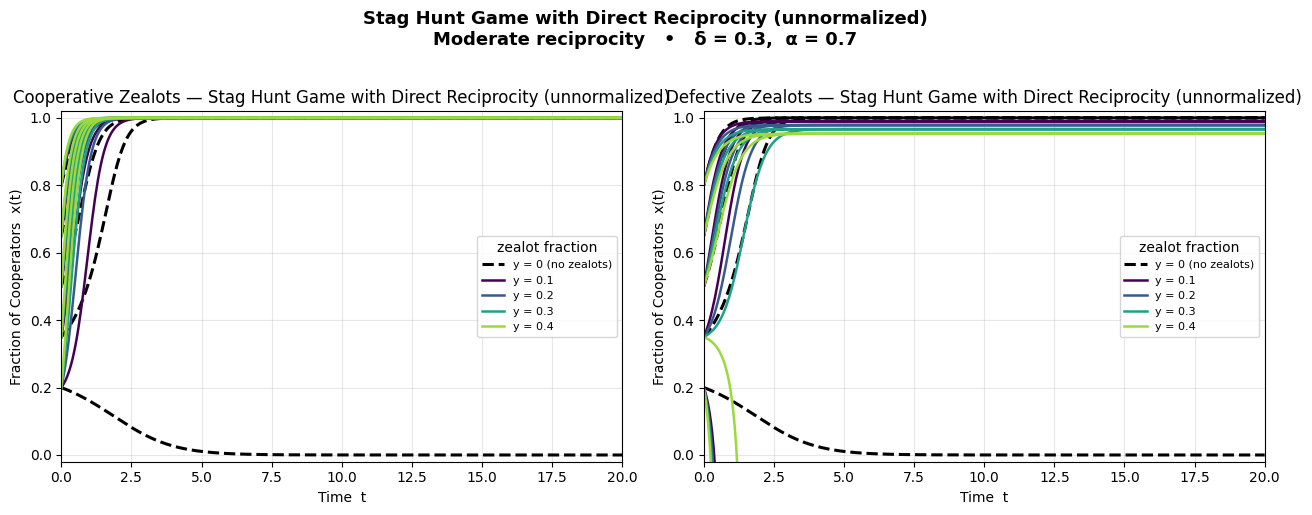

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Moderate reciprocity   |   δ = 0.5,  α = 0.7


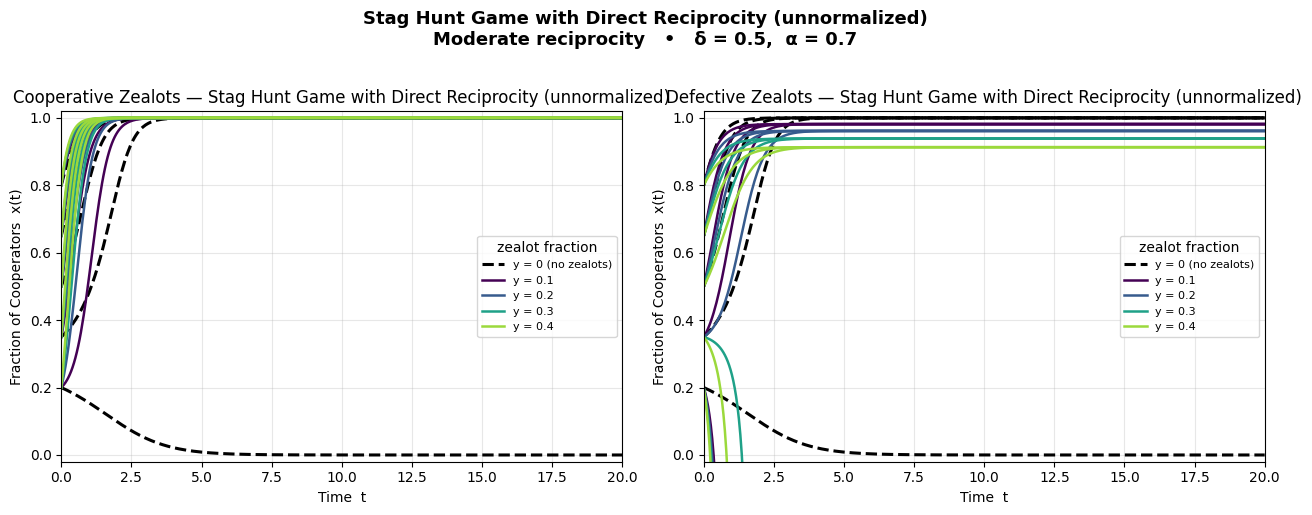

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Moderate reciprocity   |   δ = 0.7,  α = 0.7


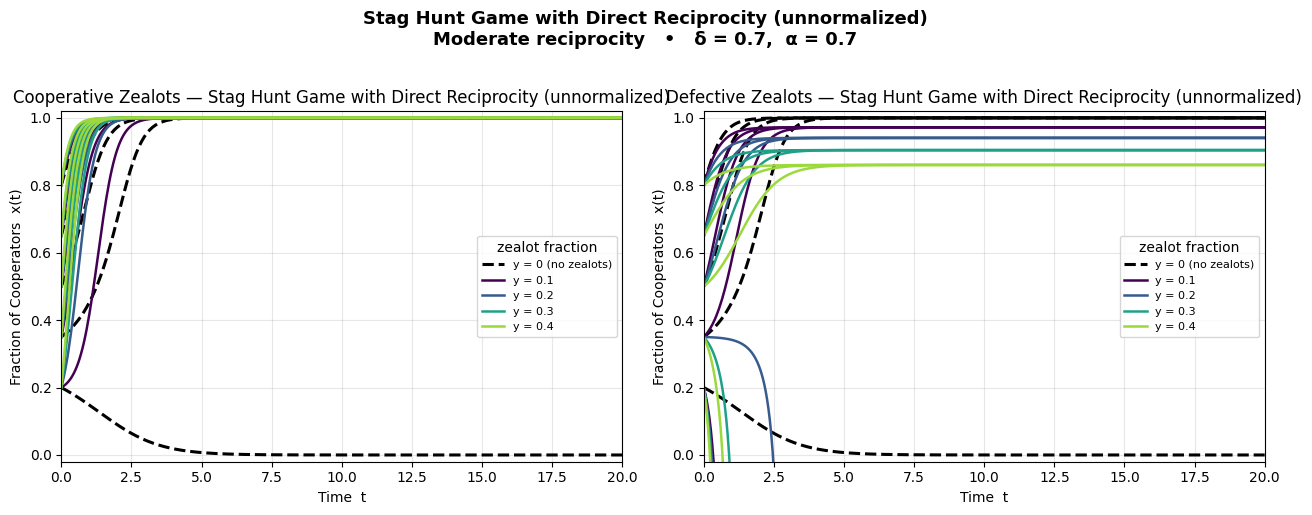

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Moderate reciprocity   |   δ = 0.9,  α = 0.7


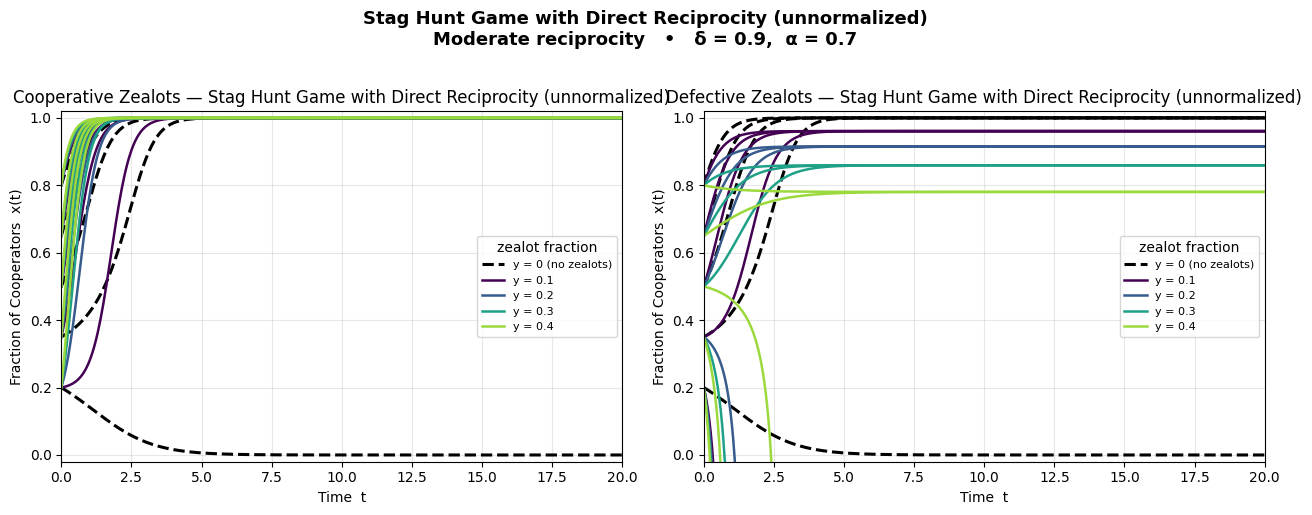

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Strong reciprocity   |   δ = 0.1,  α = 0.9


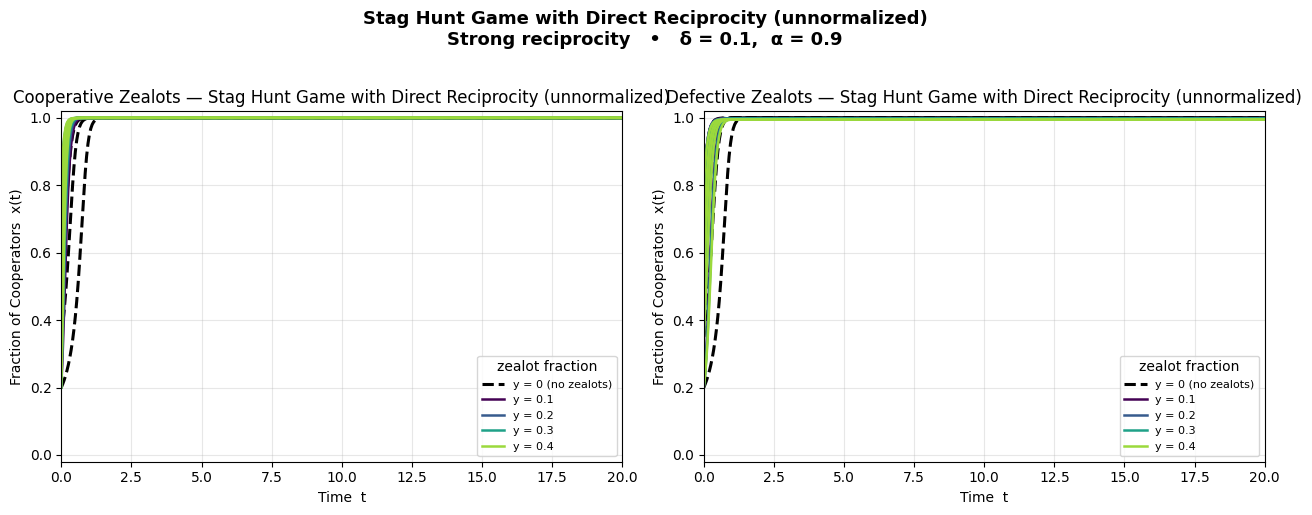

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Strong reciprocity   |   δ = 0.3,  α = 0.9


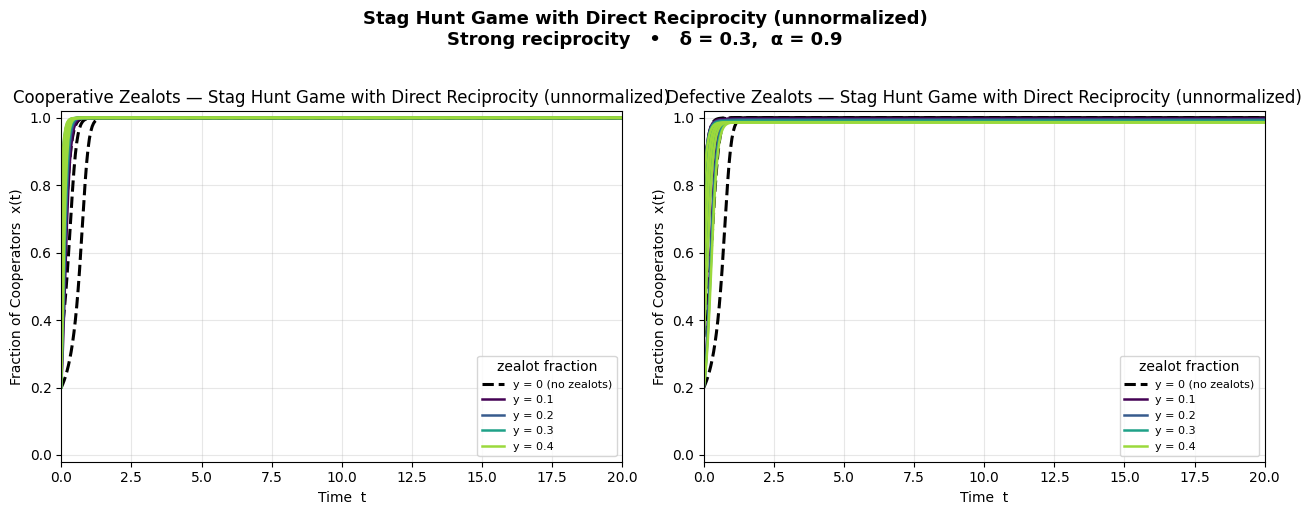

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Strong reciprocity   |   δ = 0.5,  α = 0.9


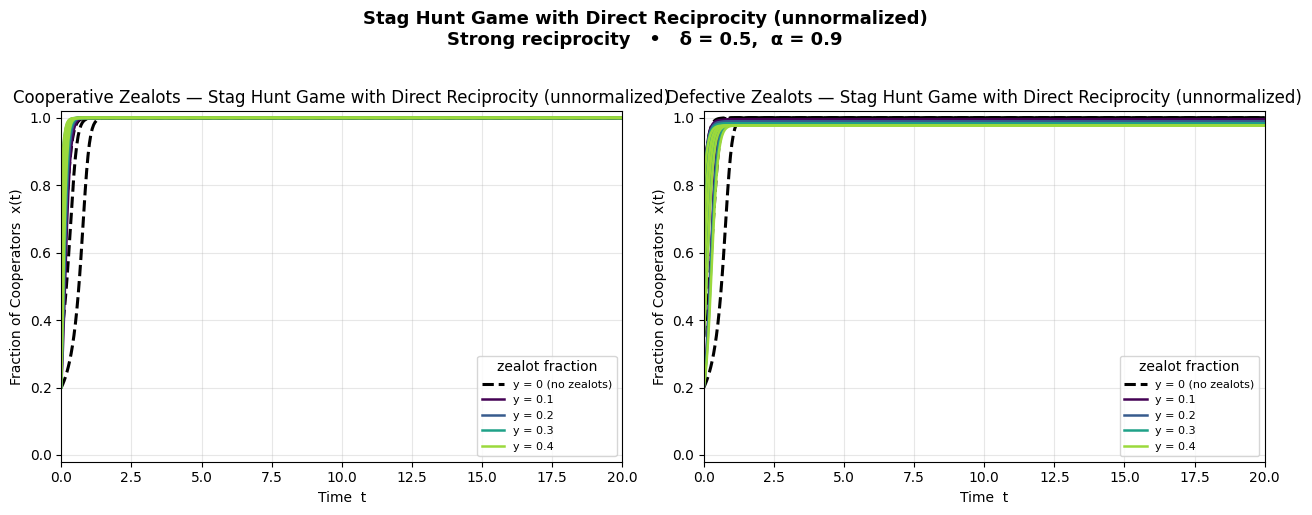

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Strong reciprocity   |   δ = 0.7,  α = 0.9


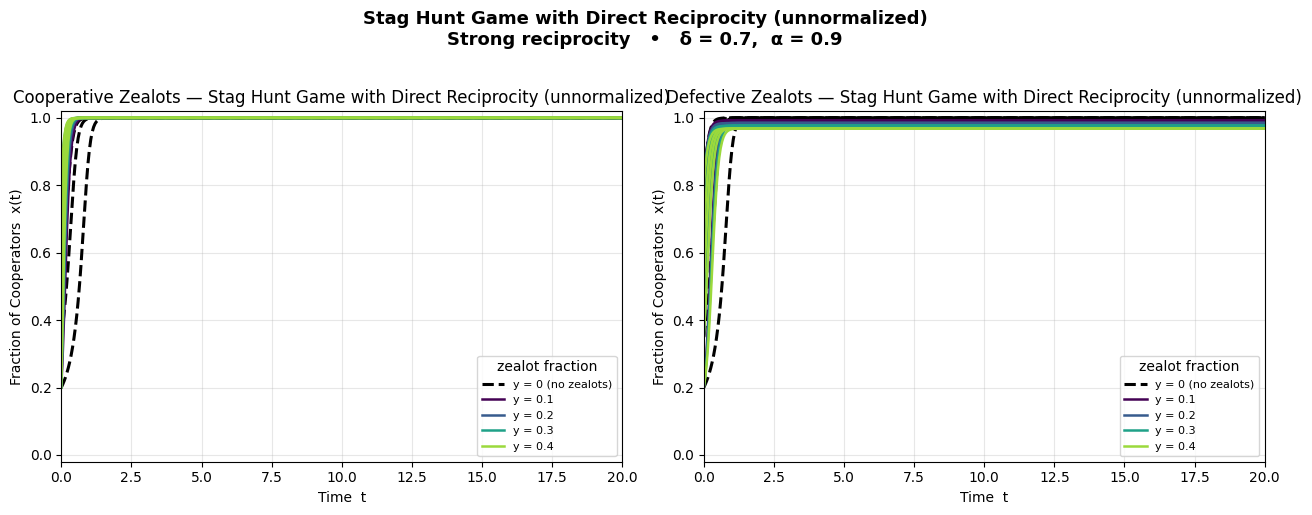

Stag Hunt Game with Direct Reciprocity (unnormalized)   |   Strong reciprocity   |   δ = 0.9,  α = 0.9


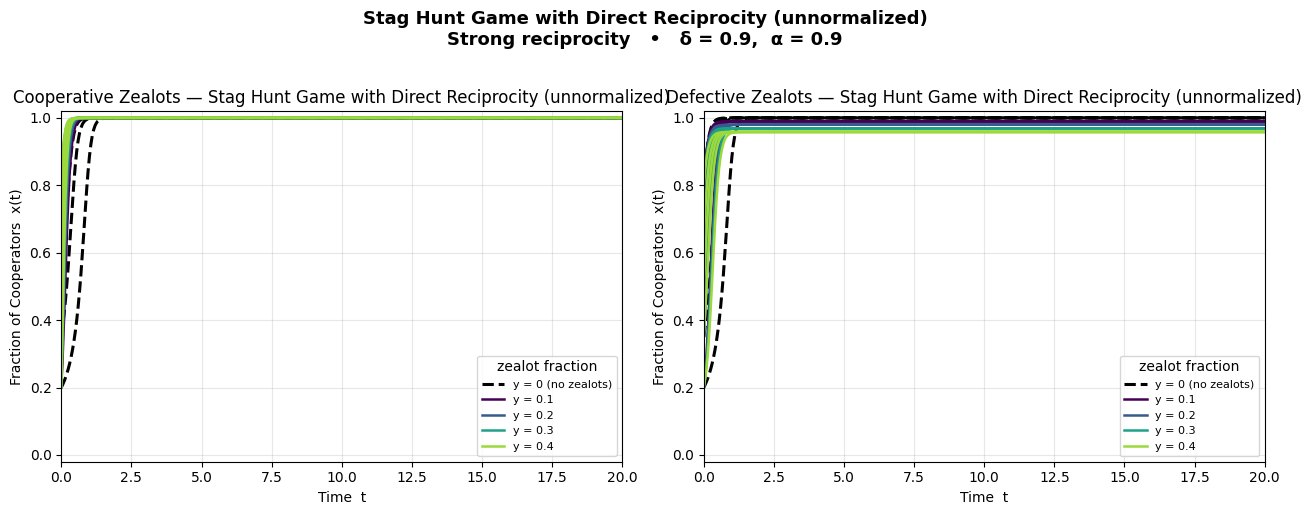

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# GAME:  STAG HUNT  with  DIRECT RECIPROCITY  (UNNORMALIZED)
# =====================================================================

GAME_NAME = "Stag Hunt Game with Direct Reciprocity (unnormalized)"

# -------------------------------------------------
# PARAMETER SWEEPS
# -------------------------------------------------
delta_values = [0.1, 0.3, 0.5, 0.7, 0.9]
alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]

zealot_values = [0.0, 0.1, 0.2, 0.3, 0.4]
initial_conditions = [0.2, 0.35, 0.5, 0.65, 0.8]

tspan = (0, 20)
t     = np.linspace(0, 20, 400)

colors = ['k'] + list(plt.cm.viridis(np.linspace(0, 0.85, len(zealot_values) - 1)))
styles = ['--'] + ['-'] * (len(zealot_values) - 1)
widths = [2.2] + [1.8] * (len(zealot_values) - 1)

def reciprocity_level(a):
    if a <= 0.2:   return "Weak reciprocity"
    elif a <= 0.5: return "Low reciprocity"
    elif a <= 0.8: return "Moderate reciprocity"
    else:          return "Strong reciprocity"


# -------------------------------------------------
# NO ZEALOTS  (unchanged — was already unnormalized)
#   dx/dt = x(1-x)[-1 + x(1/(1-α) + 1 - δ)]
# -------------------------------------------------
def no_zealots_rhs(t, x, delta, alpha):
    x = x[0]
    K = 1.0 / (1.0 - alpha)
    dx = x * (1 - x) * (-1 + x * (K + 1 - delta))
    return [dx]


# -------------------------------------------------
# ZEALOUS COOPERATORS (UNNORMALIZED)
#   dx/dt = (1-x)[(x+yc)/(1-α) - 1 + x(1-δ)]
# -------------------------------------------------
def coop_rhs(t, x, delta, alpha, yc):
    x = x[0]
    K = 1.0 / (1.0 - alpha)
    dx = (1 - x) * ((x + yc) * K - 1 + x * (1 - delta))
    return [dx]


# -------------------------------------------------
# ZEALOUS DEFECTORS (UNNORMALIZED)
#   dx/dt = (1-x) x /(1-α) + (1-x+yd)[-1 + x(1-δ)]
# -------------------------------------------------
def defect_rhs(t, x, delta, alpha, yd):
    x = x[0]
    K = 1.0 / (1.0 - alpha)
    dx = (1 - x) * x * K + (1 - x + yd) * (-1 + x * (1 - delta))
    return [dx]


# =====================================================================
# MAIN TRAJECTORY LOOP
# =====================================================================
for alpha in alpha_values:
    for delta in delta_values:

        rec_lbl = reciprocity_level(alpha)

        print("=" * 72)
        print(f"{GAME_NAME}   |   {rec_lbl}   |   δ = {delta},  α = {alpha}")
        print("=" * 72)

        fig, ax = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(
            f"{GAME_NAME}\n{rec_lbl}   •   δ = {delta},  α = {alpha}",
            fontsize=13, fontweight='bold', y=1.02
        )

        for k, y in enumerate(zealot_values):
            lbl = "y = 0 (no zealots)" if y == 0 else f"y = {y}"

            # -------- Cooperative zealots panel --------
            for j, x0 in enumerate(initial_conditions):
                if y == 0.0:
                    sol = solve_ivp(no_zealots_rhs, tspan, [x0],
                                    args=(delta, alpha),
                                    t_eval=t, rtol=1e-8, atol=1e-10)
                else:
                    sol = solve_ivp(coop_rhs, tspan, [x0],
                                    args=(delta, alpha, y),
                                    t_eval=t, rtol=1e-8, atol=1e-10)
                ax[0].plot(sol.t, sol.y[0],
                           color=colors[k], ls=styles[k], lw=widths[k],
                           label=lbl if j == 0 else None)

            # -------- Defective zealots panel --------
            for j, x0 in enumerate(initial_conditions):
                if y == 0.0:
                    sol = solve_ivp(no_zealots_rhs, tspan, [x0],
                                    args=(delta, alpha),
                                    t_eval=t, rtol=1e-8, atol=1e-10)
                else:
                    sol = solve_ivp(defect_rhs, tspan, [x0],
                                    args=(delta, alpha, y),
                                    t_eval=t, rtol=1e-8, atol=1e-10)
                ax[1].plot(sol.t, sol.y[0],
                           color=colors[k], ls=styles[k], lw=widths[k],
                           label=lbl if j == 0 else None)

        ax[0].set_title(f"Cooperative Zealots — {GAME_NAME}")
        ax[1].set_title(f"Defective Zealots — {GAME_NAME}")

        for a in ax:
            a.set_xlim(0, 20)
            a.set_ylim(-0.02, 1.02)
            a.grid(True, alpha=0.3)
            a.set_xlabel("Time  t")
            a.set_ylabel("Fraction of Cooperators  x(t)")
            a.legend(fontsize=8, loc="best", title="zealot fraction")

        plt.tight_layout()
        plt.show()

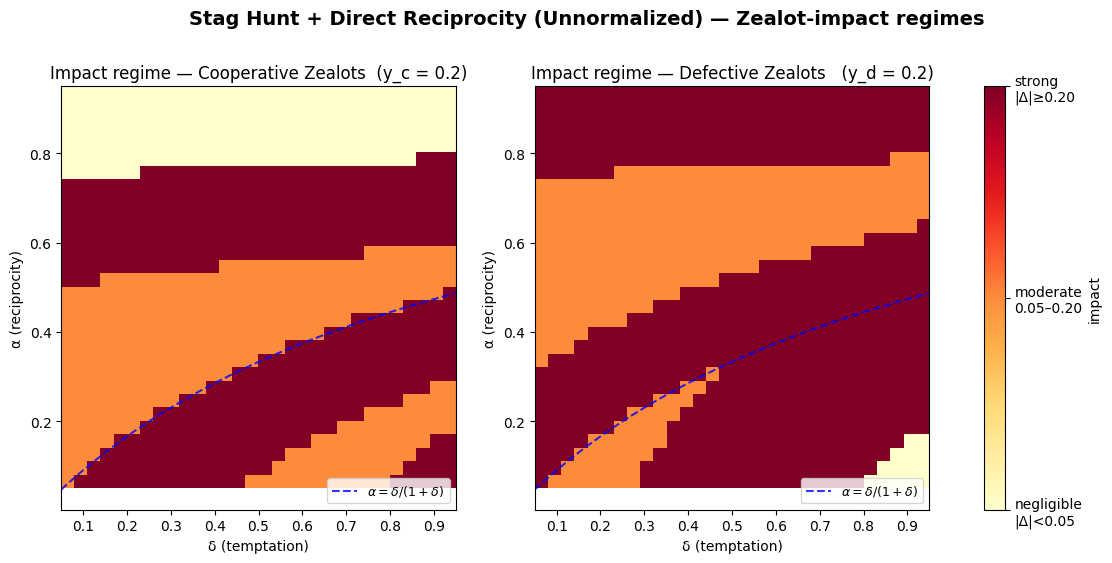


============ COOPERATIVE ZEALOTS (y_c = 0.2) ============
 STRONG    : α ∈ [0.05, 0.79], δ ∈ [0.05, 0.95]
 MODERATE  : α ∈ [0.05, 0.58], δ ∈ [0.05, 0.95]
 NEGLIGIBLE: α ∈ [0.76, 0.95], δ ∈ [0.05, 0.95]

============ DEFECTIVE ZEALOTS (y_d = 0.2) ============
 STRONG    : α ∈ [0.05, 0.95], δ ∈ [0.05, 0.95]
 MODERATE  : α ∈ [0.05, 0.79], δ ∈ [0.05, 0.95]
 NEGLIGIBLE: α ∈ [0.05, 0.14], δ ∈ [0.83, 0.95]


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =====================================================================
# Stag Hunt + Direct Reciprocity — UNNORMALIZED — Impact Classification
# =====================================================================

def no_zealots_rhs(t, x, delta, alpha):
    xv = min(1.0, max(0.0, x[0]))
    K = 1.0 / (1.0 - alpha)
    return [xv * (1 - xv) * (-1 + xv * (K + 1 - delta))]

def coop_rhs(t, x, delta, alpha, yc):
    xv = min(1.0, max(0.0, x[0]))
    K = 1.0 / (1.0 - alpha)
    return [(1 - xv) * ((xv + yc) * K - 1 + xv * (1 - delta))]

def defect_rhs(t, x, delta, alpha, yd):
    xv = min(1.0, max(0.0, x[0]))
    K = 1.0 / (1.0 - alpha)
    return [(1 - xv) * xv * K + (1 - xv + yd) * (-1 + xv * (1 - delta))]

def steady_state(rhs, args, x0=0.5, T=200):
    try:
        sol = solve_ivp(rhs, (0, T), [x0], args=args,
                        t_eval=[T], rtol=1e-8, atol=1e-10,
                        method='LSODA')
        if not sol.success or len(sol.y) == 0:
            return x0
        v = float(np.asarray(sol.y)[0, -1])
        if not np.isfinite(v):
            return x0
        return max(0.0, min(1.0, v))
    except Exception:
        return x0

def avg_steady(rhs, args):
    return np.mean([steady_state(rhs, args, x0=ic) for ic in (0.2, 0.5, 0.8)])

# ---- Parameter grid ----
alpha_grid = np.linspace(0.05, 0.95, 30)
delta_grid = np.linspace(0.05, 0.95, 30)
y_test = 0.2

X0  = np.zeros((len(alpha_grid), len(delta_grid)))
DXc = np.zeros_like(X0)
DXd = np.zeros_like(X0)

for i, a in enumerate(alpha_grid):
    for j, d in enumerate(delta_grid):
        base = avg_steady(no_zealots_rhs, (d, a))
        xc   = avg_steady(coop_rhs,       (d, a, y_test))
        xd   = avg_steady(defect_rhs,     (d, a, y_test))
        base_eff   = base
        coop_eff   = (1 - y_test) * xc + y_test
        defect_eff = (1 - y_test) * xd
        X0[i, j]  = base_eff
        DXc[i, j] = coop_eff - base_eff
        DXd[i, j] = defect_eff - base_eff

# ---- Classification ----
def classify(dx):
    a = np.abs(dx)
    out = np.zeros_like(a)
    out[(a >= 0.05) & (a < 0.20)] = 1
    out[a >= 0.20] = 2
    return out

Cc = classify(DXc)
Cd = classify(DXd)

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, C, title in zip(axes, [Cc, Cd],
                        [f"Cooperative Zealots  (y_c = {y_test})",
                         f"Defective Zealots   (y_d = {y_test})"]):
    im = ax.imshow(C, origin='lower', aspect='auto',
                   extent=[delta_grid[0], delta_grid[-1], alpha_grid[0], alpha_grid[-1]],
                   cmap='YlOrRd', vmin=0, vmax=2)
    ax.set_title(f"Impact regime — {title}")
    ax.set_xlabel("δ (temptation)")
    ax.set_ylabel("α (reciprocity)")
    d_line = np.linspace(delta_grid[0], delta_grid[-1], 200)
    a_line = d_line / (1 + d_line)
    ax.plot(d_line, a_line, 'b--', lw=1.5, alpha=0.8,
            label=r'$\alpha = \delta/(1+\delta)$')
    ax.legend(loc='lower right', fontsize=9)

cbar = plt.colorbar(im, ax=axes.ravel().tolist(),
                    ticks=[0, 1, 2], label='impact')
cbar.ax.set_yticklabels(['negligible\n|Δ|<0.05',
                         'moderate\n0.05–0.20',
                         'strong\n|Δ|≥0.20'])
plt.suptitle("Stag Hunt + Direct Reciprocity (Unnormalized) — Zealot-impact regimes",
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

# ---- Print ranges ----
def bbox(mask, ag, bg):
    if not mask.any(): return None
    ai, bi = np.where(mask)
    return (ag[ai.min()], ag[ai.max()], bg[bi.min()], bg[bi.max()])

print("\n============ COOPERATIVE ZEALOTS (y_c = 0.2) ============")
for lvl, name in [(2, 'STRONG'), (1, 'MODERATE'), (0, 'NEGLIGIBLE')]:
    box = bbox(Cc == lvl, alpha_grid, delta_grid)
    if box: print(f" {name:10s}: α ∈ [{box[0]:.2f}, {box[1]:.2f}], δ ∈ [{box[2]:.2f}, {box[3]:.2f}]")

print("\n============ DEFECTIVE ZEALOTS (y_d = 0.2) ============")
for lvl, name in [(2, 'STRONG'), (1, 'MODERATE'), (0, 'NEGLIGIBLE')]:
    box = bbox(Cd == lvl, alpha_grid, delta_grid)
    if box: print(f" {name:10s}: α ∈ [{box[0]:.2f}, {box[1]:.2f}], δ ∈ [{box[2]:.2f}, {box[3]:.2f}]")